# ridge 모델 분석 및 What-if 시나리오 예측 (검단신도시)

(1) 라이브러리 임포트 및 한글 폰트 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# 한글 폰트 설정
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)

(2) 데이터 불러오기

In [2]:
train_folder = r"C:\Users\user22\Desktop\아파트 값 예측"
test_folder = r"C:\Users\user22\Desktop\아파트 값 예측"

df_all = pd.read_csv(train_folder + r"\new_city2.csv", encoding='utf-8-sig')
df_train = df_all[df_all['도시명'].isin(['광교', '판교', '운정'])].copy()
df_test = pd.read_csv(test_folder + r"\geomdan_merged2.csv", encoding='utf-8-sig')

(3) 전처리

In [3]:
# 거래금액
df_train['거래금액(만원)'] = df_train['거래금액(만원)'].str.replace(',', '').astype(int)
df_test['거래금액(만원)'] = df_test['거래금액(만원)'].str.replace(',', '').astype(int)

# 전용 면적당 가격 계산
df_train['m2당가격'] = df_train['거래금액(만원)'] / df_train['전용면적(㎡)']
df_test['m2당가격'] = df_test['거래금액(만원)'] / df_test['전용면적(㎡)']

# 발표후경과년수 3년 미만 제거
df_train = df_train[df_train['발표후경과년수'] >= 3]
df_test = df_test[df_test['발표후경과년수'] >= 3]

# 검단 2022년 이하 훈련에 포함, 2023년 이후 테스트
df_geomdan_train = df_test[df_test['계약연도'] <= 2022].copy()
df_test = df_test[df_test['계약연도'] >= 2023].copy()
df_train = pd.concat([df_train, df_geomdan_train], ignore_index=True)

(4) 이상치 제거

In [4]:
# 이상치 제거
print(f"이상치 제거 전 데이터 건수: {len(df_train)}")

# 전용면적 33㎡ 미만 제거
df_train = df_train[df_train['전용면적(㎡)'] >= 33]
print(f"전용면적 33㎡ 미만 제거 후: {len(df_train)}")

# m2당가격 z-score 기준 이상치 제거
mean = df_train['m2당가격'].mean()
std = df_train['m2당가격'].std()
z_scores = (df_train['m2당가격'] - mean) / std
df_train = df_train[z_scores.abs() <= 2]
print(f"z-score 이상치 제거 후: {len(df_train)}")

print(f"\n훈련 데이터: {len(df_train)}건")
print(f"테스트 데이터: {len(df_test)}건")

이상치 제거 전 데이터 건수: 59779
전용면적 33㎡ 미만 제거 후: 59664
z-score 이상치 제거 후: 55950

훈련 데이터: 55950건
테스트 데이터: 8152건


(5) 독립변수/타겟 설정 및 표준화

In [5]:
features = ['건축년도', '층',
            '지하철호선개수', '기차역까지의거리',
            '가장 가까운 지하철역까지의 거리', '가장 가까운 IC와의 거리',
            '발표후경과년수', 'CPI', '계약연도', '서울도심거리',
            '단지별_세대수', '도시별_세대수']

df_train = df_train.dropna(subset=features + ['m2당가격'])
df_test = df_test.dropna(subset=features + ['m2당가격'])

train_input = df_train[features]
train_target = df_train['m2당가격']
test_input = df_test[features]
test_target = df_test['m2당가격']

# 표준화
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

(6) 최적 alpha 탐색

In [6]:
train_score = []
test_score = []
alpha_list = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
models = []

for alpha in alpha_list:
    ridge_a = Ridge(alpha=alpha)
    ridge_a.fit(train_scaled, train_target)
    train_score.append(ridge_a.score(train_scaled, train_target))
    test_score.append(ridge_a.score(test_scaled, test_target))
    models.append(ridge_a)

best_idx = test_score.index(max(test_score))
best_alpha = alpha_list[best_idx]
ridge_best = models[best_idx]

print(f"\n최적 alpha: {best_alpha}")
print(f"훈련 R²: {ridge_best.score(train_scaled, train_target):.4f}")
print(f"테스트 R²: {ridge_best.score(test_scaled, test_target):.4f}")


최적 alpha: 0.0001
훈련 R²: 0.8221
테스트 R²: 0.7294


(7) 예측 아파트 기본 특성값

In [7]:
엘리프_기본 = {
    '건축년도': 2027,
    '층': 10,
    '지하철호선개수': 2,
    '기차역까지의거리': 15.6213,
    '가장 가까운 지하철역까지의 거리': 1.206,
    '가장 가까운 IC와의 거리': 4.867,
    '발표후경과년수': 21,
    'CPI': 122.6,
    '계약연도': 2027,
    '서울도심거리': 26.5,
    '단지별_세대수': 669,
    '도시별_세대수': 60833
}

(8) 시나리오 목록

In [8]:
시나리오_목록 = {
    '현재': 엘리프_기본.copy(),
    '발표 후 25년': {**엘리프_기본, '발표후경과년수': 25, '계약연도': 2031, 'CPI': 136.4},
    '지하철 추가': {**엘리프_기본, '지하철호선개수': 3, '가장 가까운 지하철역까지의 거리': 0.5},
    '복합 시나리오': {**엘리프_기본, '발표후경과년수': 25, '계약연도': 2031, 'CPI': 136.4,
                  '지하철호선개수': 3, '가장 가까운 지하철역까지의 거리': 0.5},
}

(9) 층수별 x 시나리오별 예측

In [9]:
면적 = 84.0
층수_목록 = {'저층 (3층)': 3, '중층 (10층)': 10, '고층 (20층)': 20}

print(f"\n{'='*60}")
print(f"파밀리에 엘리프 층수별 × 시나리오별 예측 (84㎡)")
print(f"{'='*60}")

층수_결과 = {}
for 층이름, 층값 in 층수_목록.items():
    층수_결과[층이름] = []
    for 시나리오명, 값 in 시나리오_목록.items():
        입력값 = dict(값)
        입력값['층'] = 층값
        입력 = pd.DataFrame([입력값])[features]
        입력_scaled = ss.transform(입력)
        예측_m2 = ridge_best.predict(입력_scaled)[0]
        예측_금액 = int(예측_m2 * 면적)
        층수_결과[층이름].append(예측_금액)
        print(f"{층이름} | {시나리오명}: {예측_금액:,}만원 ({예측_금액/10000:.1f}억)")


파밀리에 엘리프 층수별 × 시나리오별 예측 (84㎡)
저층 (3층) | 현재: 55,516만원 (5.6억)
저층 (3층) | 발표 후 25년: 61,266만원 (6.1억)
저층 (3층) | 지하철 추가: 61,759만원 (6.2억)
저층 (3층) | 복합 시나리오: 67,508만원 (6.8억)
중층 (10층) | 현재: 56,426만원 (5.6억)
중층 (10층) | 발표 후 25년: 62,175만원 (6.2억)
중층 (10층) | 지하철 추가: 62,668만원 (6.3억)
중층 (10층) | 복합 시나리오: 68,417만원 (6.8억)
고층 (20층) | 현재: 57,724만원 (5.8억)
고층 (20층) | 발표 후 25년: 63,473만원 (6.3억)
고층 (20층) | 지하철 추가: 63,966만원 (6.4억)
고층 (20층) | 복합 시나리오: 69,716만원 (7.0억)


(10) 층수별 그래프 보기

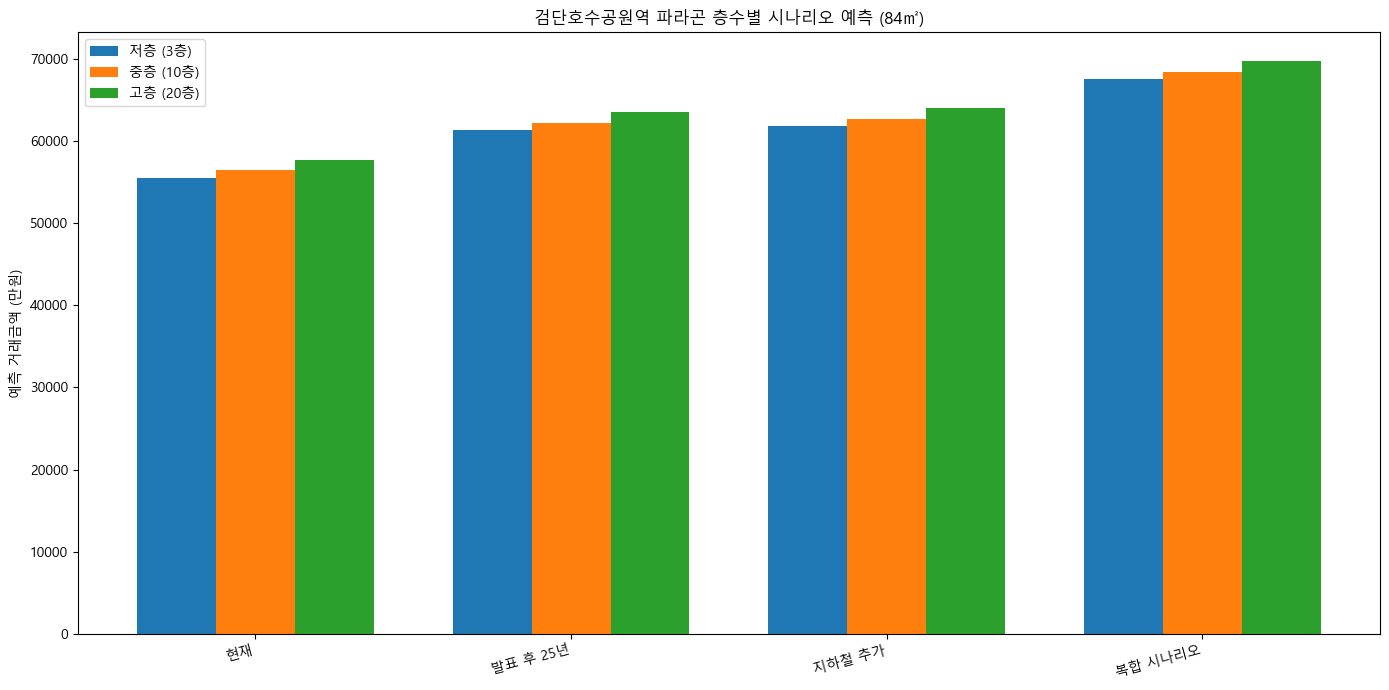

In [10]:
x = np.arange(len(시나리오_목록))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 7))
for i, (층이름, 값들) in enumerate(층수_결과.items()):
    ax.bar(x + i * width, 값들, width, label=층이름)
ax.set_xticks(x + width)
ax.set_xticklabels(시나리오_목록.keys(), rotation=15, ha='right')
ax.set_ylabel('예측 거래금액 (만원)')
ax.set_title('검단호수공원역 파라곤 층수별 시나리오 예측 (84㎡)')
ax.legend()
plt.tight_layout()
plt.show()